In [ ]:
!pip -q install -U timm kagglehub scikit-learn pandas matplotlib seaborn tqdm

In [ ]:
import os
import gc
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_curve,
    roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
import kagglehub

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA H100 80GB HBM3


In [ ]:
CFG = {
    "dataset_slug": "usmanshams/tbx-11",
    "img_size": 224,
    "batch_size": 16,
    "num_workers": 0,   # важно для Colab
    "epochs": 15,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
    "test_size": 0.15,
    "val_size_from_train": 0.1765,   # ~70/15/15
    "use_amp": True,
    "patience": 5,
    "models": [
        "vit_base_patch16_224",
        "deit_base_patch16_224",
        "swin_tiny_patch4_window7_224"
    ],
    "output_dir": "/content/tbx11k_outputs"
}

os.makedirs(CFG["output_dir"], exist_ok=True)

In [ ]:
dataset_root = kagglehub.dataset_download(CFG["dataset_slug"])
dataset_root = Path(dataset_root)

print("Dataset root:", dataset_root)
print("Top-level contents:")
for p in sorted(dataset_root.iterdir()):
    print("-", p.name)

Using Colab cache for faster access to the 'tbx-11' dataset.
Dataset root: /kaggle/input/tbx-11
Top-level contents:
- TBX11K


In [ ]:
def find_dir_by_name(root: Path, target_name: str):
    matches = [p for p in root.rglob("*") if p.is_dir() and p.name.lower() == target_name.lower()]
    if len(matches) == 0:
        raise FileNotFoundError(f"Directory '{target_name}' not found inside {root}")
    return matches[0]

imgs_dir = find_dir_by_name(dataset_root, "imgs")
lists_dir = find_dir_by_name(dataset_root, "lists")

print("imgs_dir:", imgs_dir)
print("lists_dir:", lists_dir)

imgs_dir: /kaggle/input/tbx-11/TBX11K/imgs
lists_dir: /kaggle/input/tbx-11/TBX11K/lists


In [ ]:
print("Top folders inside imgs:")
for p in sorted(imgs_dir.iterdir()):
    if p.is_dir():
        print("-", p.name)

Top folders inside imgs:
- extra
- health
- sick
- tb
- test


In [ ]:
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def is_image_file(path: Path):
    return path.suffix.lower() in IMG_EXTS

def infer_label_from_relative_path(raw_path: str):
    raw_path = raw_path.strip().replace("\\", "/")
    parts = raw_path.split("/")
    if len(parts) == 0:
        return None

    top_dir = parts[0].lower()

    # TB class
    if top_dir == "tb":
        return 1

    # Non-TB class
    if top_dir in {"health", "healthy", "normal", "sick", "sick_non_tb", "non_tb", "nontb"}:
        return 0

    # unlabeled / unknown test files
    if top_dir == "test":
        return None

    return None

rows = []

for file_path in imgs_dir.rglob("*"):
    if file_path.is_file() and is_image_file(file_path):
        rel_path = file_path.relative_to(imgs_dir).as_posix()
        label = infer_label_from_relative_path(rel_path)

        rows.append({
            "relative_path": rel_path,
            "image_path": str(file_path),
            "label": label
        })

full_df = pd.DataFrame(rows)

print("All files found in imgs:", len(full_df))
print(full_df["label"].value_counts(dropna=False))
full_df.head()

All files found in imgs: 12278
label
0.0    7600
NaN    3878
1.0     800
Name: count, dtype: int64


,relative_path,image_path,label
0,tb/tb0329.png,/kaggle/input/tbx-11/TBX11K/imgs/tb/tb0329.png,1.0
1,tb/tb0139.png,/kaggle/input/tbx-11/TBX11K/imgs/tb/tb0139.png,1.0
2,tb/tb0733.png,/kaggle/input/tbx-11/TBX11K/imgs/tb/tb0733.png,1.0
3,tb/tb0100.png,/kaggle/input/tbx-11/TBX11K/imgs/tb/tb0100.png,1.0
4,tb/tb0085.png,/kaggle/input/tbx-11/TBX11K/imgs/tb/tb0085.png,1.0


In [ ]:
df = full_df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

print("Usable labeled images:", len(df))
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))
print(df.head())

Usable labeled images: 8400
label
0    7600
1     800
Name: count, dtype: int64
label
0    0.904762
1    0.095238
Name: proportion, dtype: float64
   relative_path                                      image_path  label
0  tb/tb0329.png  /kaggle/input/tbx-11/TBX11K/imgs/tb/tb0329.png      1
1  tb/tb0139.png  /kaggle/input/tbx-11/TBX11K/imgs/tb/tb0139.png      1
2  tb/tb0733.png  /kaggle/input/tbx-11/TBX11K/imgs/tb/tb0733.png      1
3  tb/tb0100.png  /kaggle/input/tbx-11/TBX11K/imgs/tb/tb0100.png      1
4  tb/tb0085.png  /kaggle/input/tbx-11/TBX11K/imgs/tb/tb0085.png      1


In [ ]:
train_val_df, test_df = train_test_split(
    df,
    test_size=CFG["test_size"],
    stratify=df["label"],
    random_state=SEED
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=CFG["val_size_from_train"],
    stratify=train_val_df["label"],
    random_state=SEED
)

print("TRAIN:", len(train_df))
print("VAL:", len(val_df))
print("TEST:", len(test_df))
print("TOTAL USED:", len(train_df) + len(val_df) + len(test_df))

TRAIN: 5879
VAL: 1261
TEST: 1260
TOTAL USED: 8400


In [ ]:
class_counts = train_df["label"].value_counts().sort_index()

num_neg = class_counts[0]
num_pos = class_counts[1]

weight_for_0 = 1.0
weight_for_1 = num_neg / num_pos

class_weights = torch.tensor(
    [weight_for_0, weight_for_1],
    dtype=torch.float32
).to(DEVICE)

print("Train class counts:")
print(class_counts)
print("Class weights:", class_weights)

Train class counts:
label
0    5319
1     560
Name: count, dtype: int64
Class weights: tensor([1.0000, 9.4982], device='cuda:0')


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
class TBXDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_ds = TBXDataset(train_df, transform=train_tf)
val_ds = TBXDataset(val_df, transform=eval_tf)
test_ds = TBXDataset(test_df, transform=eval_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False
)

print("DataLoaders created.")

DataLoaders created.


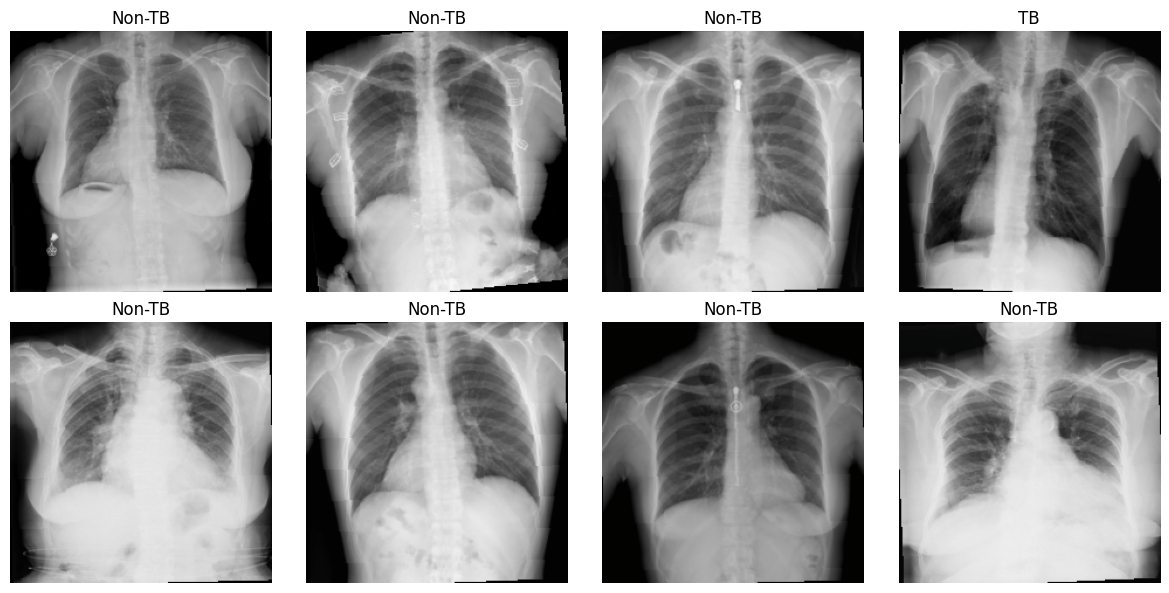

In [ ]:
label_map = {0: "Non-TB", 1: "TB"}

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(label_map[int(labels[i])])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def build_model(model_name: str, num_classes: int = 2):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=num_classes
    )
    return model.to(DEVICE)

In [ ]:
def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = recall_score(y_true, y_pred, zero_division=0)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
    return metrics

def find_best_threshold_by_f1(y_true, y_prob):
    _, _, thresholds = precision_recall_curve(y_true, y_prob)

    best_threshold = 0.5
    best_f1 = -1.0

    for t in thresholds:
        y_pred = (np.array(y_prob) >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = float(t)

    return best_threshold, best_f1

In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=CFG["use_amp"] and torch.cuda.is_available()):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)[:, 1]

        if is_train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * images.size(0)
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_labels), np.array(all_probs)

In [ ]:
def plot_training_curves(hist_df, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(hist_df["epoch"], hist_df["train_roc_auc"], label="Train")
    axes[1].plot(hist_df["epoch"], hist_df["val_roc_auc"], label="Val")
    axes[1].set_title("ROC-AUC")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(hist_df["epoch"], hist_df["train_pr_auc"], label="Train")
    axes[2].plot(hist_df["epoch"], hist_df["val_pr_auc"], label="Val")
    axes[2].set_title("PR-AUC")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.suptitle(f"Training Curves - {model_name}")
    plt.tight_layout()
    plt.show()

def plot_confusion_and_curves(y_true, y_prob, threshold, model_name):
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=["Non-TB", "TB"], yticklabels=["Non-TB", "TB"]
    )
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
    axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("FPR")
    axes[1].set_ylabel("TPR")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    axes[2].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", linewidth=2)
    axes[2].set_title("Precision-Recall Curve")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.suptitle(f"Evaluation - {model_name}")
    plt.tight_layout()
    plt.show()

In [ ]:
def train_and_evaluate(model_name):
    print("\n" + "="*80)
    print("MODEL:", model_name)
    print("="*80)

    model = build_model(model_name)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=CFG["label_smoothing"]
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=CFG["lr"],
        weight_decay=CFG["weight_decay"]
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CFG["epochs"]
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=CFG["use_amp"] and torch.cuda.is_available()
    )

    best_path = Path(CFG["output_dir"]) / f"best_{model_name.replace('/', '_')}.pth"
    best_val_pr_auc = -np.inf
    patience_counter = 0
    history = []

    for epoch in range(1, CFG["epochs"] + 1):
        start = time.time()

        train_loss, train_y, train_prob = run_one_epoch(
            model, train_loader, criterion, optimizer=optimizer, scaler=scaler
        )

        val_loss, val_y, val_prob = run_one_epoch(
            model, val_loader, criterion, optimizer=None, scaler=None
        )

        scheduler.step()

        train_metrics = compute_binary_metrics(train_y, train_prob, threshold=0.5)
        val_metrics = compute_binary_metrics(val_y, val_prob, threshold=0.5)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_roc_auc": train_metrics["roc_auc"],
            "val_roc_auc": val_metrics["roc_auc"],
            "train_pr_auc": train_metrics["pr_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "train_f1": train_metrics["f1"],
            "val_f1": val_metrics["f1"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{CFG['epochs']} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_roc_auc={val_metrics['roc_auc']:.4f} | "
            f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"time={time.time()-start:.1f}s"
        )

        if val_metrics["pr_auc"] > best_val_pr_auc:
            best_val_pr_auc = val_metrics["pr_auc"]
            patience_counter = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "history": history,
                "best_val_pr_auc": best_val_pr_auc
            }, best_path)

            print("Saved best checkpoint:", best_path)
        else:
            patience_counter += 1
            print(f"No improvement: {patience_counter}/{CFG['patience']}")

        if patience_counter >= CFG["patience"]:
            print("Early stopping triggered.")
            break

    ckpt = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])

    _, val_y, val_prob = run_one_epoch(
        model, val_loader, criterion, optimizer=None, scaler=None
    )

    best_threshold, best_val_f1 = find_best_threshold_by_f1(val_y, val_prob)
    print(f"Best threshold from validation: {best_threshold:.4f} | best val F1: {best_val_f1:.4f}")

    test_loss, test_y, test_prob = run_one_epoch(
        model, test_loader, criterion, optimizer=None, scaler=None
    )

    test_metrics = compute_binary_metrics(test_y, test_prob, threshold=best_threshold)

    test_metrics["model_name"] = model_name
    test_metrics["test_loss"] = test_loss
    test_metrics["best_threshold"] = best_threshold

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(Path(CFG["output_dir"]) / f"{model_name.replace('/', '_')}_history.csv", index=False)

    with open(Path(CFG["output_dir"]) / f"{model_name.replace('/', '_')}_metrics.json", "w") as f:
        json.dump(test_metrics, f, indent=2)

    plot_training_curves(hist_df, model_name)
    plot_confusion_and_curves(test_y, test_prob, best_threshold, model_name)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return test_metrics


MODEL: vit_base_patch16_224


  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/15 | train_loss=0.7833 | val_loss=0.6252 | val_roc_auc=0.9013 | val_pr_auc=0.6861 | val_f1=0.4386 | time=77.5s
Saved best checkpoint: /content/tbx11k_outputs/best_vit_base_patch16_224.pth


  0%|          | 0/368 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15 | train_loss=0.3835 | val_loss=0.4357 | val_roc_auc=0.9823 | val_pr_auc=0.9493 | val_f1=0.8321 | time=73.5s
No improvement: 1/5


  0%|          | 0/79 [00:00<?, ?it/s]

Best threshold from validation: 0.9256 | best val F1: 0.9217


  0%|          | 0/79 [00:00<?, ?it/s]

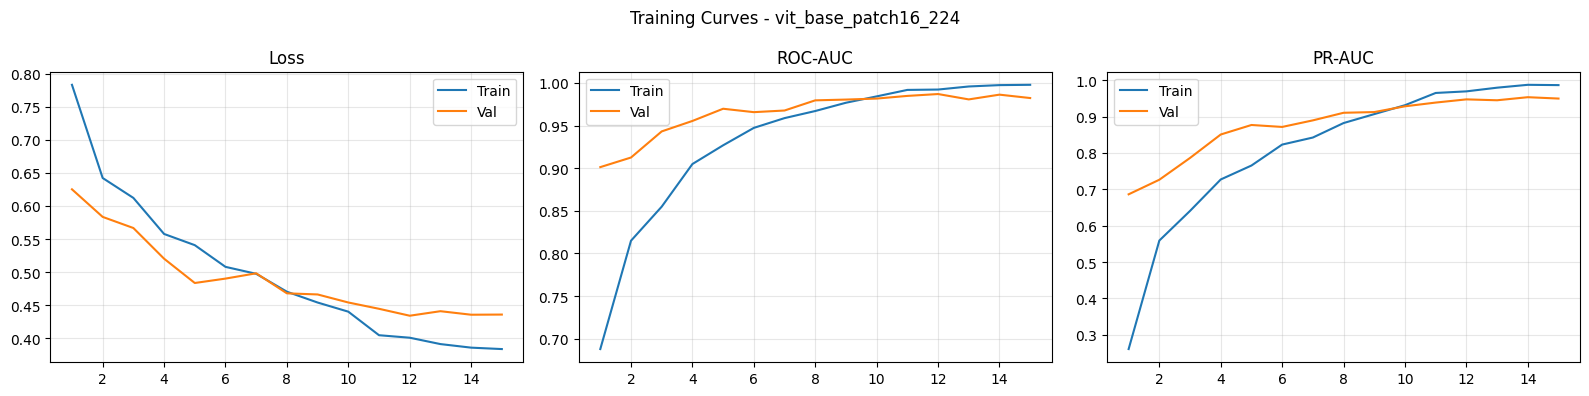

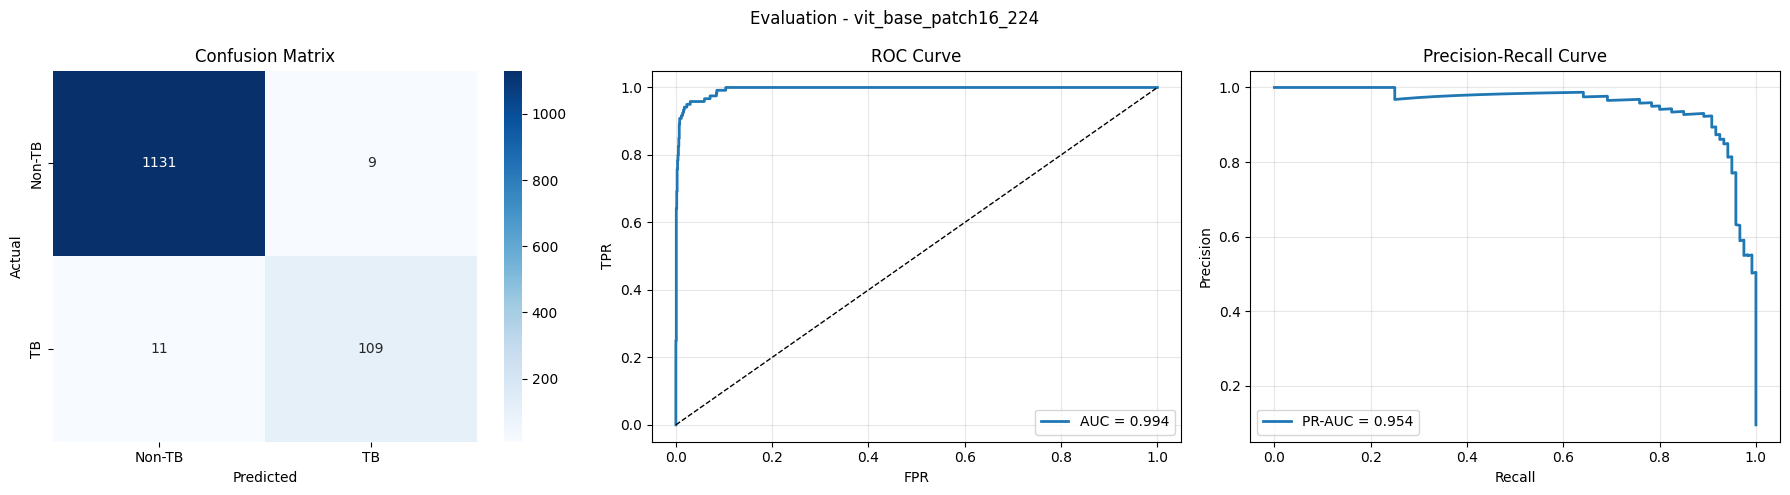


MODEL: deit_base_patch16_224


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/15 | train_loss=0.6152 | val_loss=0.4754 | val_roc_auc=0.9881 | val_pr_auc=0.9346 | val_f1=0.5856 | time=73.7s
Saved best checkpoint: /content/tbx11k_outputs/best_deit_base_patch16_224.pth


...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15 | train_loss=0.3576 | val_loss=0.3873 | val_roc_auc=0.9871 | val_pr_auc=0.9778 | val_f1=0.9388 | time=75.4s
No improvement: 1/5


  0%|          | 0/79 [00:00<?, ?it/s]

Best threshold from validation: 0.9687 | best val F1: 0.9614


  0%|          | 0/79 [00:00<?, ?it/s]

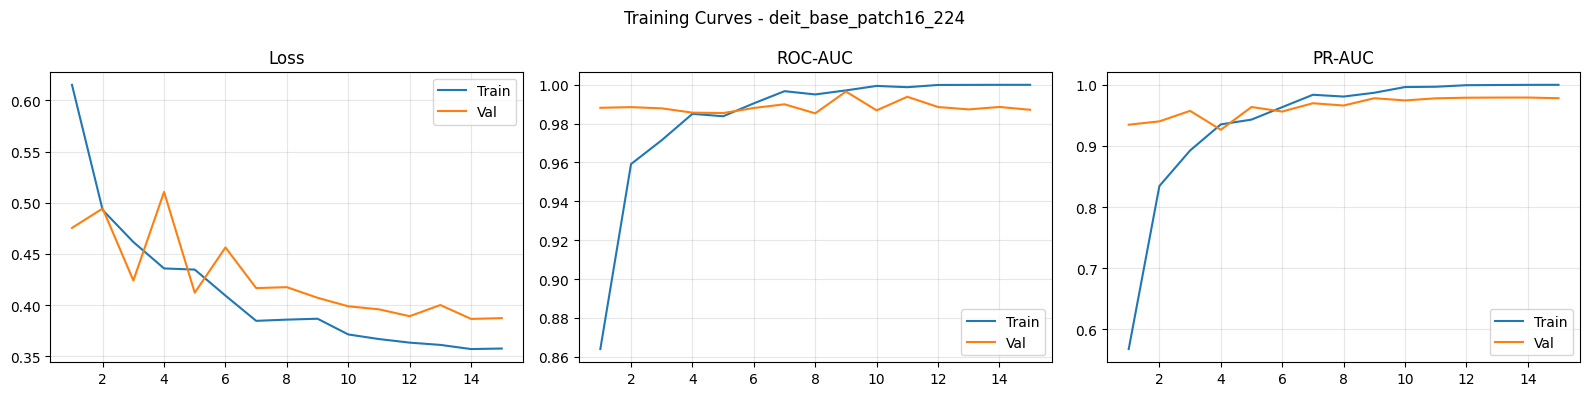

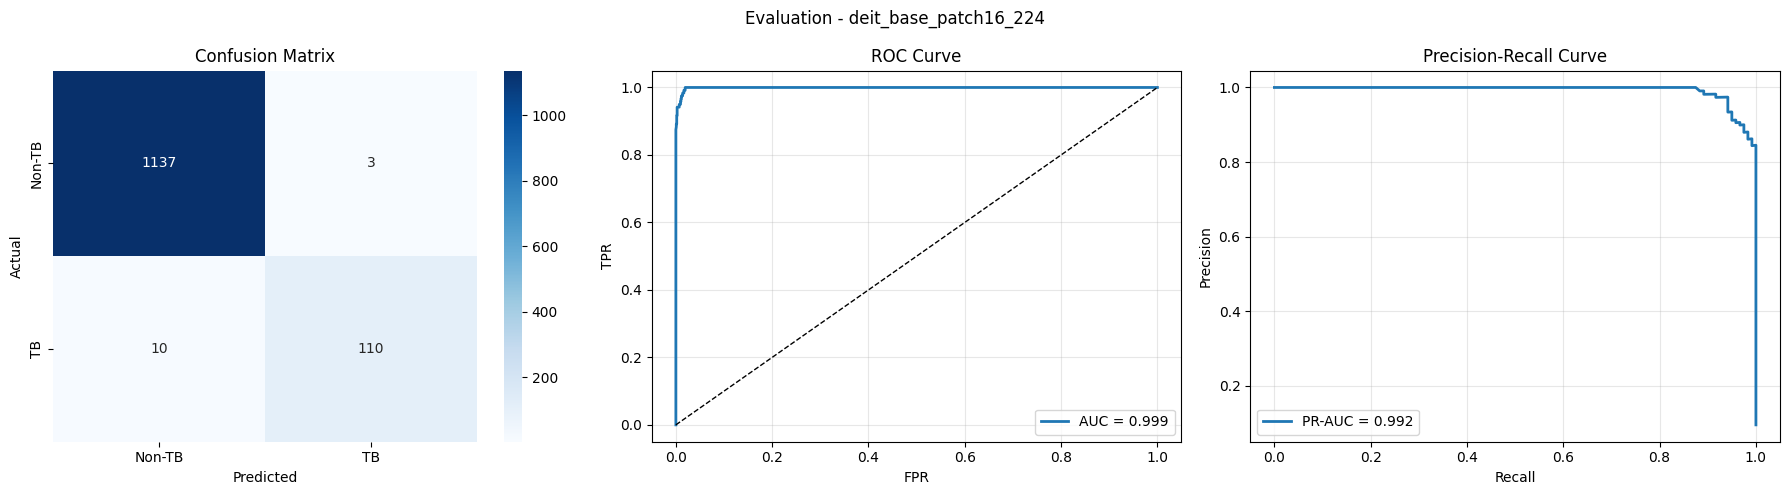


MODEL: swin_tiny_patch4_window7_224


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  0%|          | 0/368 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/15 | train_loss=0.6406 | val_loss=0.5186 | val_roc_auc=0.9605 | val_pr_auc=0.8265 | val_f1=0.5817 | time=79.1s
Saved best checkpoint: /content/tbx11k_outputs/best_swin_tiny_patch4_window7_224.pth


...

  0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15 | train_loss=0.3631 | val_loss=0.3832 | val_roc_auc=0.9994 | val_pr_auc=0.9951 | val_f1=0.9705 | time=77.0s
No improvement: 3/5


  0%|          | 0/79 [00:00<?, ?it/s]

Best threshold from validation: 0.8315 | best val F1: 0.9746


  0%|          | 0/79 [00:00<?, ?it/s]

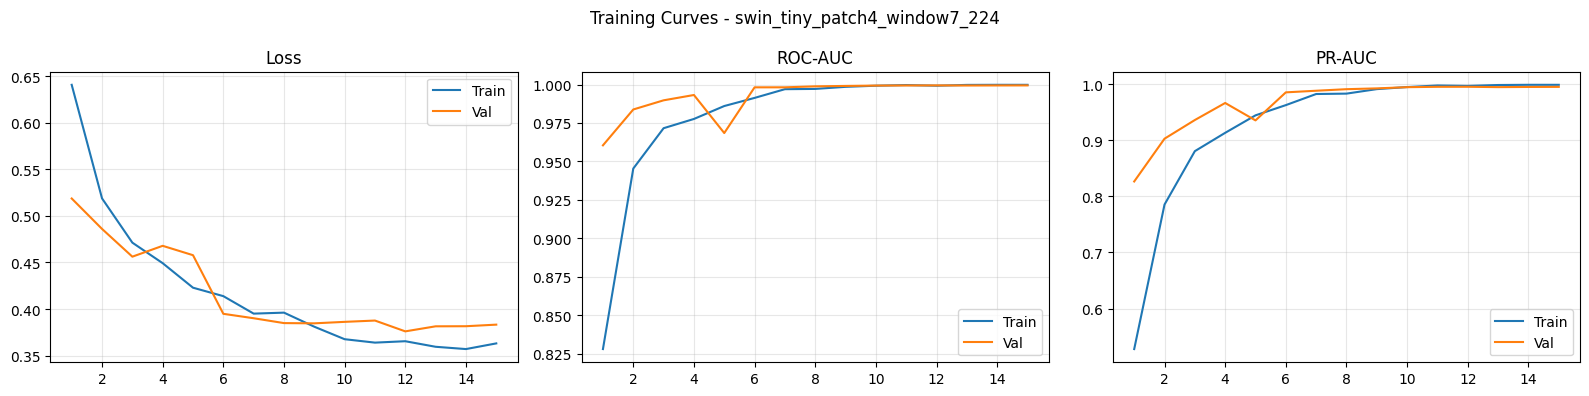

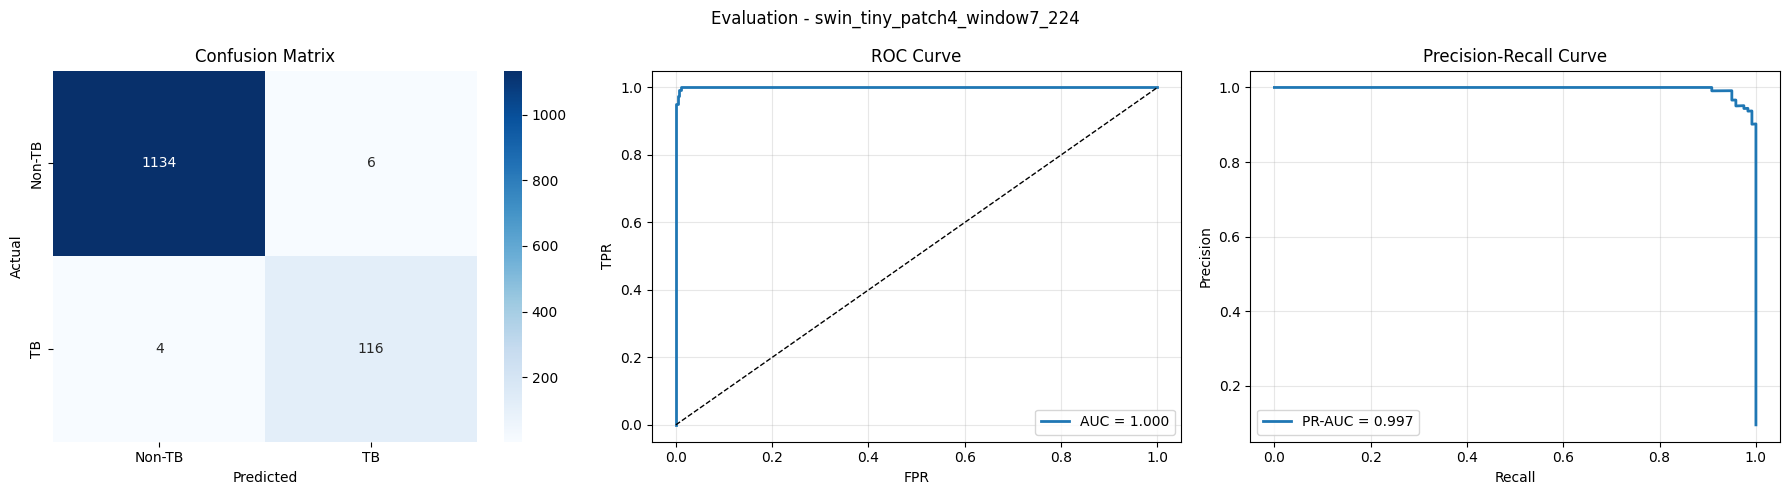

,model_name,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,mcc,test_loss,best_threshold,tn,fp,fn,tp
0,swin_tiny_patch4_window7_224,0.999642,0.996729,0.992063,0.980702,0.950820,0.966667,0.994737,0.958678,0.954328,0.373895,0.831485,1134,6,4,116
1,deit_base_patch16_224,0.999141,0.992420,0.989683,0.957018,0.973451,0.916667,0.997368,0.944206,0.939042,0.390137,0.968709,1137,3,10,110
2,vit_base_patch16_224,0.994236,0.953932,0.984127,0.950219,0.923729,0.908333,0.992105,0.915966,0.907242,0.418259,0.925634,1131,9,11,109


In [ ]:
all_results = []

for model_name in CFG["models"]:
    result = train_and_evaluate(model_name)
    all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df = results_df[[
    "model_name",
    "roc_auc",
    "pr_auc",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "mcc",
    "test_loss",
    "best_threshold",
    "tn", "fp", "fn", "tp"
]].sort_values(
    by=["pr_auc", "roc_auc", "f1"],
    ascending=False
).reset_index(drop=True)

results_df.to_csv(Path(CFG["output_dir"]) / "final_results.csv", index=False)
results_df

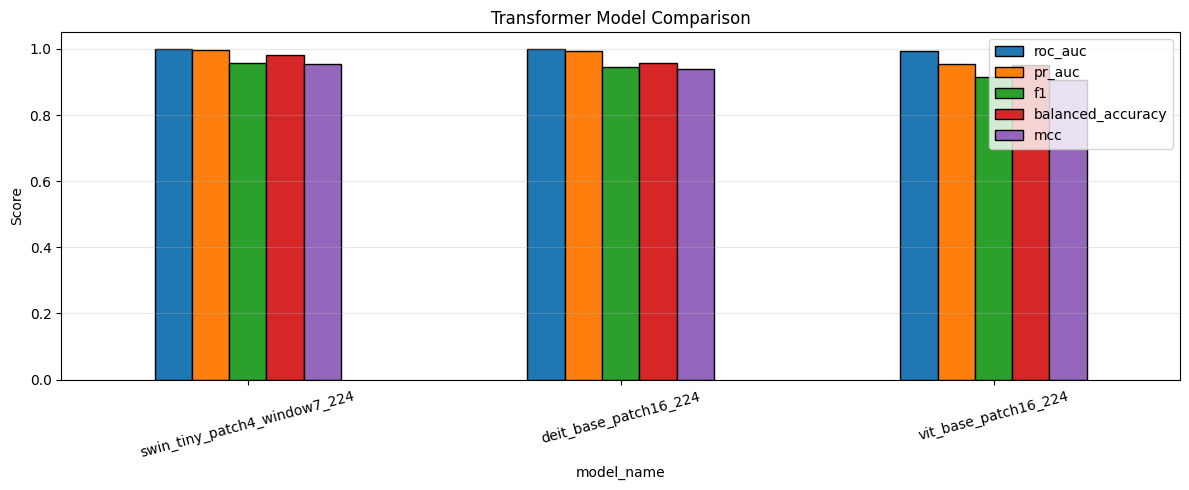

In [ ]:
plot_df = results_df.set_index("model_name")[["roc_auc", "pr_auc", "f1", "balanced_accuracy", "mcc"]]

plot_df.plot(kind="bar", figsize=(12, 5), edgecolor="black")
plt.title("Transformer Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
train_df.to_csv(Path(CFG["output_dir"]) / "train_split.csv", index=False)
val_df.to_csv(Path(CFG["output_dir"]) / "val_split.csv", index=False)
test_df.to_csv(Path(CFG["output_dir"]) / "test_split.csv", index=False)

print("Splits saved.")

Splits saved.
